# Extension Observation - Notebook Final

Ce notebook couvre uniquement l'extension `kinematics` vs `occupancy_grid`.

Objectifs:
- verifier la qualite des observations,
- executer un protocole d'entrainement/evaluation reproductible,
- analyser les ecarts entre representations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
from IPython import get_ipython
from IPython.display import display, Markdown, Image

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

from common import seed_env
from observation_extension_config import build_config
from common_observation_extension import (
    EXT_ARTIFACTS_DIR,
    DEFAULT_EXTENSION_SETTINGS,
    make_extension_env,
    preprocess_observation,
)
from custom_dqn_observation_extension import ExtensionDQNPolicy
from evaluate_observation_extension import evaluate_all as evaluate_observation_extension

print("Backend matplotlib:", matplotlib.get_backend())
print("Dossier artefacts extension:", EXT_ARTIFACTS_DIR)
EXT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

Backend matplotlib: inline
Dossier artefacts extension: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension


## 1. Verification des observations Occupancy Grid

Cette section verifie l'orientation, l'echelle et la forme des tenseurs avant entrainement.

Features OccupancyGrid: ['presence', 'x', 'y', 'vx', 'vy']
Shape grille fine (C,H,W): (5, 22, 22)


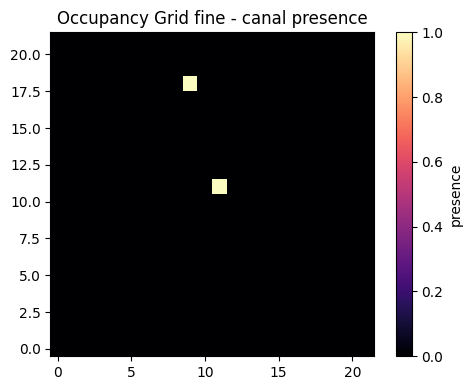

In [7]:
config_fine = build_config("occupancy_grid")
config_fine["observation"]["grid_step"] = [2.5, 2.5]
config_fine["observation"]["features"] = ["presence", "x", "y", "vx", "vy"]

fine_env = make_extension_env("occupancy_grid")
fine_env.unwrapped.configure(config_fine)
obs_fine, _ = seed_env(fine_env, 0)
processed_fine = preprocess_observation(obs_fine, "occupancy_grid")

print("Features OccupancyGrid:", config_fine["observation"]["features"])
print("Shape grille fine (C,H,W):", processed_fine.shape)

plt.figure(figsize=(5, 4))
plt.imshow(processed_fine[0], origin="lower", cmap="magma")
plt.colorbar(label="presence")
plt.title("Occupancy Grid fine - canal presence")
plt.tight_layout()
plt.show()

fine_env.close()

Features OccupancyGrid: ['presence', 'x', 'y', 'vx', 'vy']
Shape brute: (5, 22, 22)
Shape preprocessee (C,H,W): (5, 22, 22)


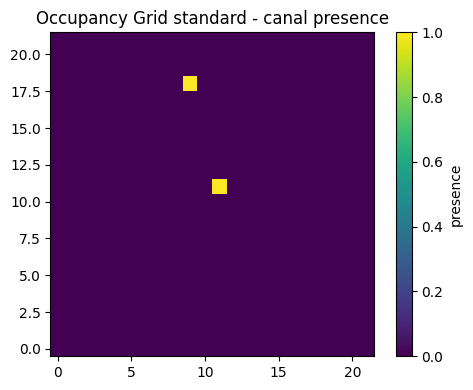

In [8]:
config_std = build_config("occupancy_grid")
config_std["observation"]["features"] = ["presence", "x", "y", "vx", "vy"]

occupancy_env = make_extension_env("occupancy_grid")
occupancy_env.unwrapped.configure(config_std)
obs, _ = seed_env(occupancy_env, 0)
processed = preprocess_observation(obs, "occupancy_grid")

print("Features OccupancyGrid:", config_std["observation"]["features"])
print("Shape brute:", np.asarray(obs).shape)
print("Shape preprocessee (C,H,W):", processed.shape)

presence = processed[0]
plt.figure(figsize=(5, 4))
plt.imshow(presence, origin="lower", cmap="viridis")
plt.colorbar(label="presence")
plt.title("Occupancy Grid standard - canal presence")
plt.tight_layout()
plt.show()

occupancy_env.close()

## 2. Reevaluation des modeles existants (50 episodes)

Cette section reutilise les modeles deja presents dans `artifacts/observation_extension`.

Parametres utilises:
- seeds train: 0, 1, 2
- episodes eval: 50
- eval seeds: 4000 a 4049

In [ ]:
from pathlib import Path
import importlib

import custom_dqn_observation_extension as ext_dqn_module
import evaluate_observation_extension as ext_eval_module

# Recharge les modules depuis les fichiers, utile apres modifications de code en cours de session.
ext_dqn_module = importlib.reload(ext_dqn_module)
ext_eval_module = importlib.reload(ext_eval_module)
evaluate_observation_extension = ext_eval_module.evaluate_all

ext_train_seeds = [0, 1, 2]
ext_eval_seeds = list(range(4000, 4030))
RUN_REEVALUATION = True

for mode in ["kinematics", "occupancy_grid"]:
    for seed in ext_train_seeds:
        model_path = EXT_ARTIFACTS_DIR / mode / f"seed_{seed}" / "checkpoints" / "final_model.pt"
        if not model_path.exists():
            raise FileNotFoundError(f"Modele introuvable: {model_path}")

if RUN_REEVALUATION:
    print("lancement de l'evaluation")
    ext_summary_df = evaluate_observation_extension(
        observation_modes=["kinematics", "occupancy_grid"],
        train_seeds=ext_train_seeds,
        eval_seeds=ext_eval_seeds,
        device="cpu",
    )
    display(ext_summary_df)
else:
    ext_csv = EXT_ARTIFACTS_DIR / "comparison_summary.csv"
    if ext_csv.exists():
        print("chargement de comparison_summary.csv")
        ext_summary_df = pd.read_csv(ext_csv).sort_values(["observation_mode", "train_seed"]).reset_index(drop=True)
        display(ext_summary_df)
    else:
        print("Aucun resume existant")

## 3. Analyse quantitative et graphiques (50 episodes)

In [30]:
ext_csv = EXT_ARTIFACTS_DIR / "comparison_summary.csv"

if ext_csv.exists():
    ext_df = pd.read_csv(ext_csv).sort_values(["observation_mode", "train_seed"]).reset_index(drop=True)
    display(Markdown("### Resultats par run"))
    display(ext_df)

    metric_cols = [
        "mean_reward",
        "reward_std",
        "reward_median",
        "crash_rate",
        "mean_episode_length",
        "mean_speed",
    ]

    grouped_ext = ext_df.groupby("observation_mode")[metric_cols].agg(["mean", "std", "median"]).round(4)
    display(Markdown("### Agregation par mode"))
    display(grouped_ext)

    modes = set(ext_df["observation_mode"].unique())
    if {"kinematics", "occupancy_grid"}.issubset(modes):
        pivot_ext = ext_df.groupby("observation_mode")[metric_cols].mean()
        delta_ext = pd.DataFrame(index=metric_cols)
        delta_ext["occupancy_minus_kinematics"] = pivot_ext.loc["occupancy_grid"] - pivot_ext.loc["kinematics"]
        denom = pivot_ext.loc["kinematics"].replace(0, np.nan).abs()
        delta_ext["delta_relatif_pct"] = 100.0 * delta_ext["occupancy_minus_kinematics"] / denom
        display(Markdown("### Delta Occupancy Grid - Kinematics"))
        display(delta_ext.round(4))
else:
    print("Fichier introuvable:", ext_csv)

### Resultats par run

,observation_mode,train_seed,num_eval_episodes,mean_reward,reward_std,reward_median,crash_rate,mean_episode_length,mean_speed
0,kinematics,0,30,19.809861,2.460202,20.454545,0.066667,28.800000,20.586921
1,kinematics,1,30,14.171100,6.304996,14.700152,0.733333,18.733333,24.193050
2,kinematics,2,30,15.794058,6.900853,19.907368,0.533333,21.500000,23.172193
3,occupancy_grid,0,30,20.977309,4.982434,22.491490,0.166667,27.633333,23.031178
4,occupancy_grid,1,30,20.700641,0.572310,20.454545,0.000000,30.000000,20.339900
5,occupancy_grid,2,30,19.219167,5.611567,21.169345,0.166667,26.766667,21.782990


### Agregation par mode

mean_reward                  reward_std                  \
                        mean     std   median       mean     std  median   
observation_mode                                                           
kinematics           16.5917  2.9028  15.7941     5.2220  2.4103  6.3050   
occupancy_grid       20.2990  0.9454  20.7006     3.7221  2.7459  4.9824   

                 reward_median                  crash_rate                  \
                          mean     std   median       mean     std  median   
observation_mode                                                             
kinematics             18.3540  3.1761  19.9074     0.4444  0.3421  0.5333   
occupancy_grid         21.3718  1.0335  21.1693     0.1111  0.0962  0.1667   

                 mean_episode_length                  mean_speed          \
                                mean     std   median       mean     std   
observation_mode                                                           
kinematics                   23.0111  5.2007  21.5000    22.6507  1.8588   
occupancy_grid               28.1333  1.6737  27.6333    21.7180  1.3468   

                           
                   median  
observation_mode           
kinematics        23.1722  
occupancy_grid    21.7830

### Delta Occupancy Grid - Kinematics

,occupancy_minus_kinematics,delta_relatif_pct
mean_reward,3.7074,22.3447
reward_std,-1.4999,-28.7229
reward_median,3.0178,16.4420
crash_rate,-0.3333,-75.0000
mean_episode_length,5.1222,22.2598
mean_speed,-0.9327,-4.1177


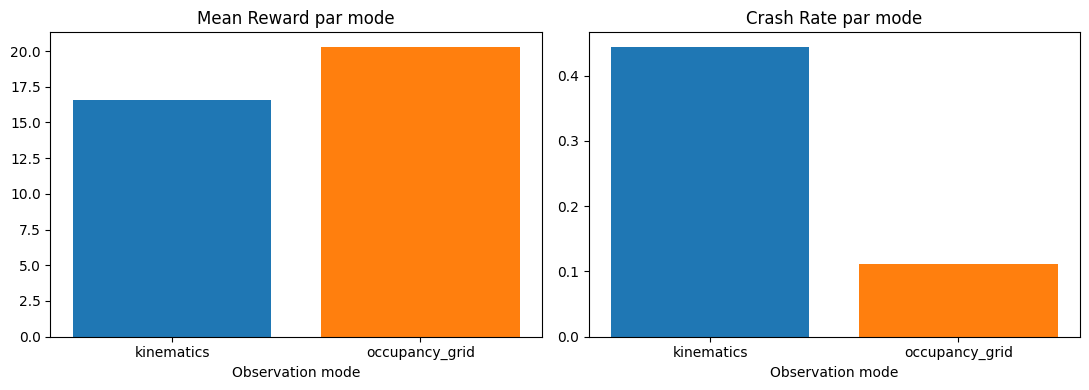

Figure enregistree: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\observation_mode_summary_50eval.png


C:\Users\quent\AppData\Local\Temp\ipykernel_33924\2763468647.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rewards_by_mode, labels=["kinematics", "occupancy_grid"])


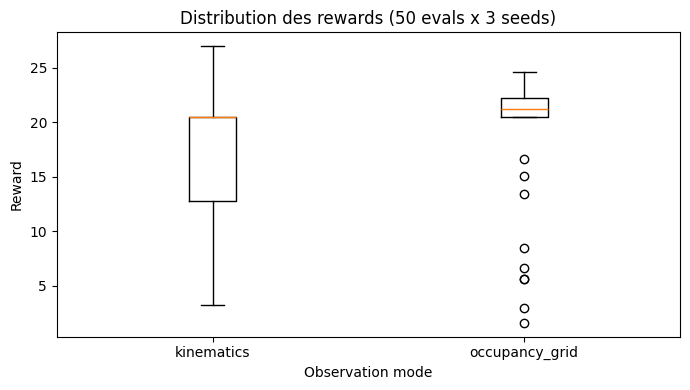

Figure enregistree: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\reward_distribution_boxplot_50eval.png


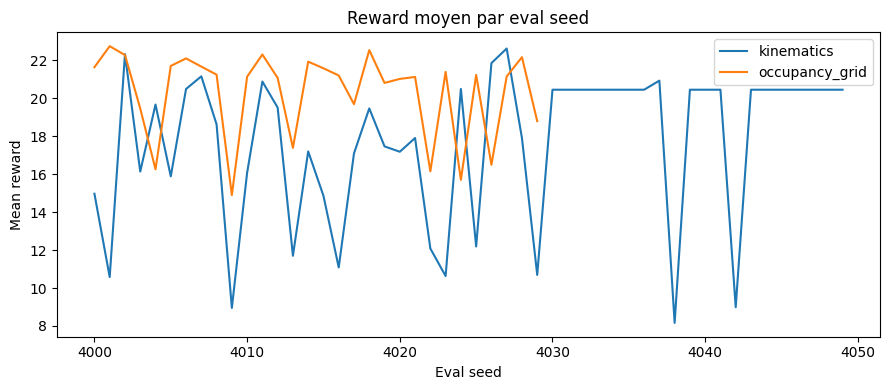

Figure enregistree: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\reward_per_eval_seed_50eval.png


In [22]:
if ext_csv.exists():
    ext_df = pd.read_csv(ext_csv)

    agg = ext_df.groupby("observation_mode", as_index=False).agg(
        mean_reward=("mean_reward", "mean"),
        crash_rate=("crash_rate", "mean"),
        reward_seed_std=("mean_reward", "std"),
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(agg["observation_mode"], agg["mean_reward"], color=["#1f77b4", "#ff7f0e"])
    axes[0].set_title("Mean Reward par mode")
    axes[0].set_xlabel("Observation mode")

    axes[1].bar(agg["observation_mode"], agg["crash_rate"], color=["#1f77b4", "#ff7f0e"])
    axes[1].set_title("Crash Rate par mode")
    axes[1].set_xlabel("Observation mode")

    plt.tight_layout()
    summary_plot = EXT_ARTIFACTS_DIR / "observation_mode_summary_50eval.png"
    plt.savefig(summary_plot, dpi=180)
    plt.show()
    print("Figure enregistree:", summary_plot)

    all_episodes = []
    for mode in ["kinematics", "occupancy_grid"]:
        for seed in [0, 1, 2]:
            episode_path = EXT_ARTIFACTS_DIR / mode / f"seed_{seed}" / "evaluation" / "episodes.csv"
            if episode_path.exists():
                df_ep = pd.read_csv(episode_path)
                df_ep["observation_mode"] = mode
                df_ep["train_seed"] = seed
                all_episodes.append(df_ep)

    if all_episodes:
        episodes_df = pd.concat(all_episodes, ignore_index=True)

        rewards_by_mode = [
            episodes_df.loc[episodes_df["observation_mode"] == "kinematics", "reward"].values,
            episodes_df.loc[episodes_df["observation_mode"] == "occupancy_grid", "reward"].values,
        ]

        plt.figure(figsize=(7, 4))
        plt.boxplot(rewards_by_mode, labels=["kinematics", "occupancy_grid"])
        plt.title("Distribution des rewards (50 evals x 3 seeds)")
        plt.xlabel("Observation mode")
        plt.ylabel("Reward")
        plt.tight_layout()
        boxplot_path = EXT_ARTIFACTS_DIR / "reward_distribution_boxplot_50eval.png"
        plt.savefig(boxplot_path, dpi=180)
        plt.show()
        print("Figure enregistree:", boxplot_path)

        seed_curve = (
            episodes_df.groupby(["observation_mode", "episode_seed"], as_index=False)
            .agg(mean_reward=("reward", "mean"))
        )

        plt.figure(figsize=(9, 4))
        for mode in ["kinematics", "occupancy_grid"]:
            df_mode = seed_curve[seed_curve["observation_mode"] == mode].sort_values("episode_seed")
            plt.plot(df_mode["episode_seed"], df_mode["mean_reward"], label=mode)
        plt.title("Reward moyen par eval seed")
        plt.xlabel("Eval seed")
        plt.ylabel("Mean reward")
        plt.legend()
        plt.tight_layout()
        curve_path = EXT_ARTIFACTS_DIR / "reward_per_eval_seed_50eval.png"
        plt.savefig(curve_path, dpi=180)
        plt.show()
        print("Figure enregistree:", curve_path)

## 4. Visualisation qualitative (GIF)

In [23]:
# Selection automatique d'un seed train par mode (meilleur mean_reward)
summary_csv = EXT_ARTIFACTS_DIR / "comparison_summary.csv"
if not summary_csv.exists():
    raise FileNotFoundError(f"Fichier introuvable: {summary_csv}")

summary_df = pd.read_csv(summary_csv)
selection_rows = []
for mode in ["kinematics", "occupancy_grid"]:
    df_mode = summary_df[summary_df["observation_mode"] == mode]
    if df_mode.empty:
        continue
    best_row = df_mode.sort_values("mean_reward", ascending=False).iloc[0]
    selection_rows.append(best_row)

gif_selection_df = pd.DataFrame(selection_rows).reset_index(drop=True)
display(Markdown("### Seeds selectionnes pour les GIF"))
display(gif_selection_df[["observation_mode", "train_seed", "mean_reward", "crash_rate"]])

### Seeds selectionnes pour les GIF

,observation_mode,train_seed,mean_reward,crash_rate
0,kinematics,0,19.809861,0.066667
1,occupancy_grid,0,20.977309,0.166667


### GIF - kinematics | train_seed=0 | eval_seed=4037

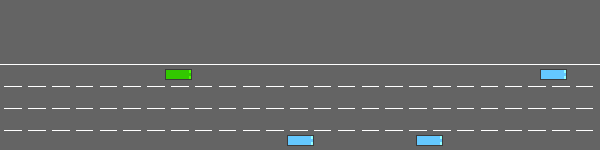

GIF enregistre: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\episode_kinematics_train0_eval4037.gif


### GIF - occupancy_grid | train_seed=0 | eval_seed=4018

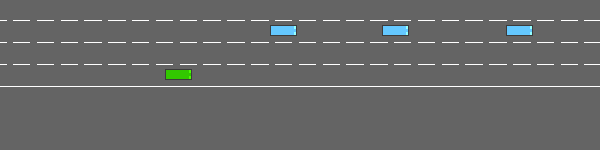

GIF enregistre: C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\episode_occupancy_grid_train0_eval4018.gif
GIF generes:
- C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\episode_kinematics_train0_eval4037.gif
- C:\Users\quent\Desktop\CentraleSupélec\RL\HighwayToRL\artifacts\observation_extension\episode_occupancy_grid_train0_eval4018.gif


In [29]:
# Generation des GIF (1 episode par mode)
from custom_dqn_observation_extension import ExtensionDQNPolicy
import torch

try:
    import imageio.v2 as imageio
except Exception as exc:
    raise ImportError(
        "Le package imageio est requis pour exporter des GIF. Installe-le puis relance cette cellule."
    ) from exc


def align_occupancy_shape(processed, expected_shape):
    """Aligne (C,H,W) sur la forme attendue par le modele: crop ou zero-pad."""
    if expected_shape is None or len(expected_shape) != 3:
        return processed

    exp_c, exp_h, exp_w = map(int, expected_shape)

    cur_c, cur_h, cur_w = map(int, processed.shape)

    if cur_c > exp_c:
        processed = processed[:exp_c, :, :]
    elif cur_c < exp_c:
        pad_c = np.zeros((exp_c - cur_c, cur_h, cur_w), dtype=processed.dtype)
        processed = np.concatenate([processed, pad_c], axis=0)

    cur_c, cur_h, cur_w = map(int, processed.shape)

    if cur_h > exp_h:
        processed = processed[:, :exp_h, :]
    elif cur_h < exp_h:
        pad_h = np.zeros((cur_c, exp_h - cur_h, cur_w), dtype=processed.dtype)
        processed = np.concatenate([processed, pad_h], axis=1)

    cur_c, cur_h, cur_w = map(int, processed.shape)

    if cur_w > exp_w:
        processed = processed[:, :, :exp_w]
    elif cur_w < exp_w:
        pad_w = np.zeros((cur_c, cur_h, exp_w - cur_w), dtype=processed.dtype)
        processed = np.concatenate([processed, pad_w], axis=2)

    return processed


def safe_policy_predict(policy, observation, expected_shape=None):
    """Predire une action en alignant la forme de l'observation si necessaire."""
    processed = preprocess_observation(observation, policy.observation_mode)

    if processed.ndim == 3 and hasattr(policy.q_network, "encoder"):
        processed = align_occupancy_shape(processed, expected_shape)

    with torch.no_grad():
        obs_tensor = torch.as_tensor(processed, dtype=torch.float32, device=policy.device).unsqueeze(0)
        action = int(policy.q_network(obs_tensor).argmax(dim=1).item())
    return action


MAX_STEPS_GIF = 120
GIF_FPS = 8
gif_paths = []

for _, row in gif_selection_df.iterrows():
    mode = str(row["observation_mode"])
    train_seed = int(row["train_seed"])

    episodes_path = EXT_ARTIFACTS_DIR / mode / f"seed_{train_seed}" / "evaluation" / "episodes.csv"
    eval_seed = 4000
    if episodes_path.exists():
        ep_df = pd.read_csv(episodes_path)
        if not ep_df.empty and "reward" in ep_df.columns and "episode_seed" in ep_df.columns:
            eval_seed = int(ep_df.sort_values("reward", ascending=False).iloc[0]["episode_seed"])

    model_path = EXT_ARTIFACTS_DIR / mode / f"seed_{train_seed}" / "checkpoints" / "final_model.pt"
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    expected_shape = tuple(checkpoint.get("observation_shape", []))
    policy = ExtensionDQNPolicy.load(model_path)

    env = make_extension_env(mode, render_mode="rgb_array")
    obs, _ = seed_env(env, eval_seed)

    frames = []
    done = False
    step = 0
    while (not done) and step < MAX_STEPS_GIF:
        frame = env.render()
        if frame is not None:
            frames.append(frame)

        action = safe_policy_predict(policy, obs, expected_shape=expected_shape)
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        step += 1

    env.close()

    if not frames:
        print(f"Aucune frame capturee pour {mode} (seed train={train_seed}, eval={eval_seed}).")
        continue

    gif_path = EXT_ARTIFACTS_DIR / f"episode_{mode}_train{train_seed}_eval{eval_seed}.gif"
    imageio.mimsave(gif_path, frames, fps=GIF_FPS)
    gif_paths.append(gif_path)

    display(Markdown(f"### GIF - {mode} | train_seed={train_seed} | eval_seed={eval_seed}"))
    display(Image(filename=str(gif_path)))
    print("GIF enregistre:", gif_path)

if not gif_paths:
    print("Aucun GIF genere.")
else:
    print("GIF generes:")
    for p in gif_paths:
        print("-", p)

## 5. Limites et interpretation

Points a retenir:
- `occupancy_grid` inclut un cout d'apprentissage plus eleve (CNN).
- la comparaison presentee repose sur 3 seeds et 30 episodes d'evaluation.
- une validation complementaire peut etre faite avec 100k-200k timesteps.

Lecture des metriques:
- `mean_reward`: plus eleve est preferable.
- `crash_rate`: plus faible est preferable.
- `reward_seed_std`: plus faible indique une meilleure stabilite inter-seeds.

In [6]:
kin_env = make_extension_env("kinematics")
kin_obs, _ = seed_env(kin_env, 0)
kin_tensor = preprocess_observation(kin_obs, "kinematics")
print(kin_tensor)
print("shape:", kin_tensor.shape)
kin_env.close()

[ 1.          0.8873327   0.75        0.3125      0.          1.
  0.09073734 -0.25       -0.04846349  0.          1.          0.20118086
 -0.25       -0.02725116  0.          1.          0.31662506  0.
 -0.01493478  0.          1.          0.42161888 -0.5        -0.04874054
  0.          1.          0.5304446   0.         -0.01763079  0.
  1.          0.6232403  -0.5        -0.04893801  0.          1.
  0.7316513  -0.5        -0.02573039  0.          1.          0.84469736
 -0.5        -0.01321867  0.          1.          0.94867593  0.
 -0.02418325  0.        ]
shape: (50,)
